## SECTION 0 — Setup & Imports

In [1]:
!pip install timm tqdm -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [3]:
import os, time, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import timm
from PIL import Image
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
warnings.filterwarnings("ignore")

# ── Paths (RunPod workspace) ──────────────────────────────────────────────────
BASE_DIR   = "/workspace/data"
NPY_DIR    = "/workspace/data/satellite_npy"
CSV_PATH   = "/workspace/data/combined_dataset.csv"
RESULTS    = "/workspace/results"

os.makedirs(f"{RESULTS}/plots", exist_ok=True)
os.makedirs(NPY_DIR, exist_ok=True)

# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ CUDA GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
    print("Using MPS with fallback")
else:
    device = torch.device("cpu")
    print("Using CPU")

# ── Platform-aware DataLoader settings ───────────────────────────────────────
is_linux   = platform.system() == "Linux"
NUM_WORKERS = 4 if is_linux else 0
PIN_MEMORY  = True if is_linux and torch.cuda.is_available() else False
print(f"Workers: {NUM_WORKERS} | pin_memory: {PIN_MEMORY}")

# ── AMP ───────────────────────────────────────────────────────────────────────
USE_AMP = torch.cuda.is_available()

# ── Image normalisation constants (ImageNet) ──────────────────────────────────
IMG_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMG_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

torch.manual_seed(42)
np.random.seed(42)
print("Setup complete ✓")


✅ CUDA GPU: NVIDIA GeForce RTX 4090
   VRAM: 25.3 GB
Workers: 4 | pin_memory: True
Setup complete ✓


## SECTION 1 — Data Loading & EDA

Shape: (7640, 22)
Date range: 2024-01-01 08:00:00 → 2026-02-02 17:00:00
Total usable rows (image present): 7635


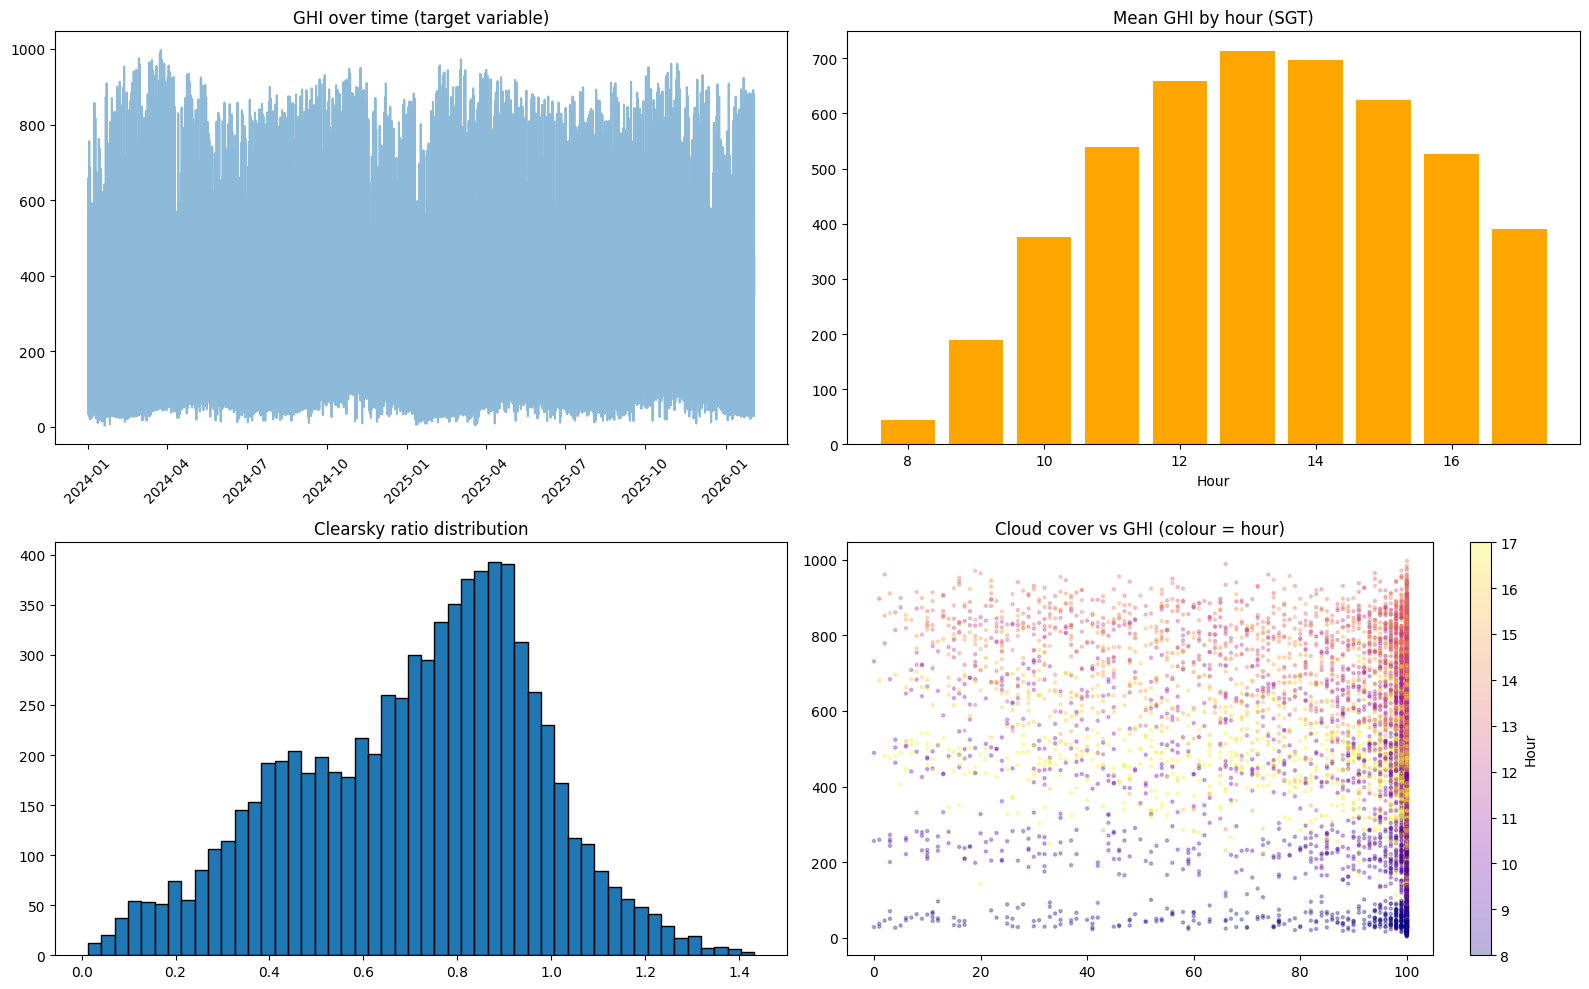


Correlation with GHI:
ghi                         1.000000
pv_actual                   0.999941
temperature_2m              0.864442
direct_normal_irradiance    0.819759
ghi_clearsky                0.807999
clearsky_ratio              0.766938
diffuse_radiation           0.524712
hour                        0.488120
wind_speed_10m              0.331613
sin_month                   0.021941
Name: ghi, dtype: float64


In [4]:
df = pd.read_csv(CSV_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# ── Remove leaky columns ──────────────────────────────────────────────────────
# pv_actual = 0.847 * ghi (r=0.9999) — drop as a feature, only keep for reference
# ghi will be used as TARGET (future values), not as an input feature for that step
LEAKY_COLS = ["pv_actual"]  # keep in df for reference but exclude from inputs

# ── Feature engineering ───────────────────────────────────────────────────────
df["clearsky_ratio"] = df["ghi"] / (df["ghi_clearsky"] + 1e-6)
df["hour"]           = df["timestamp"].dt.hour
df["month"]          = df["timestamp"].dt.month
df["sin_hour"]       = np.sin(2 * np.pi * df["hour"] / 24)
df["cos_hour"]       = np.cos(2 * np.pi * df["hour"] / 24)
df["sin_month"]      = np.sin(2 * np.pi * df["month"] / 12)
df["cos_month"]      = np.cos(2 * np.pi * df["month"] / 12)

print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Total usable rows (image present): {df['image_path'].notna().sum()}")

# ── EDA ───────────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

axs[0,0].plot(df["timestamp"], df["ghi"], alpha=0.5)
axs[0,0].set_title("GHI over time (target variable)")
axs[0,0].tick_params(axis="x", rotation=45)

hourly = df.groupby("hour")["ghi"].mean()
axs[0,1].bar(hourly.index, hourly.values, color="orange")
axs[0,1].set_title("Mean GHI by hour (SGT)")
axs[0,1].set_xlabel("Hour")

axs[1,0].hist(df["clearsky_ratio"].clip(0, 1.5), bins=50, edgecolor="black")
axs[1,0].set_title("Clearsky ratio distribution")

sc = axs[1,1].scatter(df["cloud_cover"], df["ghi"], alpha=0.3, s=5, c=df["hour"], cmap="plasma")
plt.colorbar(sc, ax=axs[1,1], label="Hour")
axs[1,1].set_title("Cloud cover vs GHI (colour = hour)")

plt.tight_layout()
plt.savefig(f"{RESULTS}/plots/eda.png", dpi=150)
plt.show()

print("\nCorrelation with GHI:")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(df[num_cols].corr()["ghi"].sort_values(ascending=False).head(10))


## SECTION 2 — Baseline Model Honest

In [5]:
# ── Tabular features for baselines ───────────────────────────────────────────
# Only use features available at time t (no future GHI leaking in)
BASELINE_FEATURES = [
    "clearsky_ratio", "cloud_cover", "temperature_2m",
    "rain", "wind_speed_10m", "relative_humidity_2m",
    "sin_hour", "cos_hour", "sin_month", "cos_month",
    "ghi_clearsky",
    # lagged GHI (past values only — available at prediction time)
    "ghi_lag1", "ghi_lag2", "ghi_lag3",
]

df["ghi_lag1"] = df["ghi"].shift(1)
df["ghi_lag2"] = df["ghi"].shift(2)
df["ghi_lag3"] = df["ghi"].shift(3)

# Targets: GHI at t+1h, t+2h, t+3h
for h in [1, 2, 3]:
    df[f"ghi_t{h}h"] = df["ghi"].shift(-h)

# Drop rows with NaN (from lags or targets)
df_clean = df.dropna(subset=BASELINE_FEATURES + ["ghi_t1h","ghi_t2h","ghi_t3h"]).copy()
print(f"Clean rows for baseline: {len(df_clean)}")

# ── Train/val/test split (temporal — no shuffling) ────────────────────────────
n = len(df_clean)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_clean.iloc[:train_end].copy()
val_df   = df_clean.iloc[train_end:val_end].copy()
test_df  = df_clean.iloc[val_end:].copy()

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

X_train = train_df[BASELINE_FEATURES].values
X_val   = val_df[BASELINE_FEATURES].values
X_test  = test_df[BASELINE_FEATURES].values

results = []
for h in [1, 2, 3]:
    y_train = train_df[f"ghi_t{h}h"].values
    y_test  = test_df[f"ghi_t{h}h"].values

    for name, model in [
        ("Linear Regression", LinearRegression()),
        ("Random Forest",     RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)),
        ("LightGBM",          lgb.LGBMRegressor(n_estimators=200, random_state=42, verbose=-1)),
    ]:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        mae  = mean_absolute_error(y_test, pred)
        r2   = r2_score(y_test, pred)
        results.append({"Model": name, "Horizon": f"t+{h}h", "MAE_Wm2": mae, "R2": r2})
        print(f"{name:20s} t+{h}h → MAE={mae:.1f} W/m²  R²={r2:.4f}")

baseline_df = pd.DataFrame(results)
baseline_df.to_csv(f"{RESULTS}/baseline_ghi_comparison.csv", index=False)
print("\nBaselines saved ✓")


Clean rows for baseline: 7634
Train: 5343 | Val: 1145 | Test: 1146
Linear Regression    t+1h → MAE=81.1 W/m²  R²=0.8266
Random Forest        t+1h → MAE=63.5 W/m²  R²=0.8813
LightGBM             t+1h → MAE=63.3 W/m²  R²=0.8809
Linear Regression    t+2h → MAE=106.0 W/m²  R²=0.7190
Random Forest        t+2h → MAE=82.5 W/m²  R²=0.8078
LightGBM             t+2h → MAE=82.1 W/m²  R²=0.8131
Linear Regression    t+3h → MAE=121.6 W/m²  R²=0.6380
Random Forest        t+3h → MAE=90.0 W/m²  R²=0.7816
LightGBM             t+3h → MAE=89.8 W/m²  R²=0.7768

Baselines saved ✓


## SECTION 3 — Image Preprocessing (PNG → NPY)

In [10]:
def save_images_as_npy(dataframe, npy_dir=NPY_DIR):
    paths = dataframe["image_path"].dropna().unique().tolist()
    total = len(paths)
    already = sum(
        1 for p in paths
        if os.path.exists(
            os.path.join(npy_dir,
                os.path.relpath(p, "/workspace/data/satellite")).replace(".png", ".npy"))
    )
    if already == total:
        print(f"All {total} .npy files already exist — skipping.")
        return
    print(f"Saving {total - already} images as .npy (skipping {already} done)...")
    start = time.time()
    for i, path in enumerate(paths):
        rel = os.path.relpath(os.path.join("/workspace", path), "/workspace/data/satellite")
        npy_path = os.path.join(npy_dir, rel).replace(".png", ".npy")
        os.makedirs(os.path.dirname(npy_path), exist_ok=True)
        if os.path.exists(npy_path):
            continue
        try:
            with Image.open(os.path.join("/workspace", path)) as img:
                arr = np.array(
                    img.convert("RGB").resize((224, 224), Image.BILINEAR),
                    dtype=np.float32) / 255.0
            np.save(npy_path, arr)
        except Exception as e:
            print(f"  Failed [{i}]: {e}")
        if (i+1) % 500 == 0 or (i+1) == total:
            elapsed = time.time() - start
            rate    = (i+1) / elapsed
            remaining = (total - i - 1) / rate if rate > 0 else 0
            print(f"  {i+1}/{total} | {elapsed/60:.1f}m | ~{remaining/60:.1f}m left | {rate:.0f} img/s")
    print("Done saving .npy files.")

save_images_as_npy(df_clean)


Saving 7625 images as .npy (skipping 0 done)...


Done saving .npy files.


In [11]:
import os
test_path = "/workspace/data/satellite/2024/01/himawari_4d_20240101_030000.png"
print(os.path.exists(test_path))
print(os.listdir("/workspace/data/satellite/2024/01/")[:5])

True
['himawari_4d_20240131_030000.png', 'himawari_4d_20240131_060000.png', 'himawari_4d_20240131_020000.png', 'himawari_4d_20240131_050000.png', 'himawari_4d_20240131_040000.png']


## SECTION 4 — Load Images into RAM

In [12]:
print("Loading all images into RAM...")
npy_cache = {}
paths = df_clean["image_path"].dropna().unique().tolist()
start = time.time()

for i, path in enumerate(paths):
    rel      = os.path.relpath(path, "/workspace/data/satellite")
    npy_path = os.path.join(NPY_DIR, rel).replace(".png", ".npy")
    if os.path.exists(npy_path):
        try:
            arr = np.load(npy_path)                          # (224,224,3) 0-1
            arr = (arr - IMG_MEAN) / IMG_STD                 # normalize
            npy_cache[path] = torch.from_numpy(
                arr.transpose(2, 0, 1)).float()              # (3,224,224)
        except Exception:
            npy_cache[path] = None
    else:
        npy_cache[path] = None
    if (i+1) % 1000 == 0 or (i+1) == len(paths):
        print(f"  {i+1}/{len(paths)} | {(time.time()-start)/60:.1f}m elapsed")

ram = psutil.virtual_memory()
print(f"\nDone. {len(npy_cache)} images in RAM.")
print(f"RAM: {ram.used/1e9:.1f} GB used / {ram.total/1e9:.1f} GB total")


Loading all images into RAM...
  1000/7625 | 0.0m elapsed
  2000/7625 | 0.0m elapsed
  3000/7625 | 0.0m elapsed
  4000/7625 | 0.0m elapsed
  5000/7625 | 0.0m elapsed
  6000/7625 | 0.0m elapsed
  7000/7625 | 0.0m elapsed
  7625/7625 | 0.0m elapsed

Done. 7625 images in RAM.
RAM: 18.2 GB used / 270.1 GB total


## SECTION 5 — Dataset & DataLoaders

**Target: GHI at t+1h, t+2h, t+3h**

**Inputs (no leakage):**
- Past 24h window of: `clearsky_ratio`, `cloud_cover`, `temperature_2m`, `rain`, `wind_speed_10m`, `relative_humidity_2m`, `sin_hour`, `cos_hour`, `sin_month`, `cos_month`, `ghi_lag1` (i.e. past GHI)
- Satellite image at time t
- Future `ghi_clearsky` (pure solar geometry — always known ahead of time)
- Gate features: clearsky_ratio, cloud_cover

In [13]:
# ── Tabular columns fed into the sequence model ───────────────────────────────
# NOTE: current GHI is excluded from TABULAR_COLS to avoid trivial prediction.
# The model must learn from cloud structure + weather to forecast future GHI.
TABULAR_COLS = [
    "clearsky_ratio", "cloud_cover", "temperature_2m",
    "rain", "wind_speed_10m", "relative_humidity_2m",
    "sin_hour", "cos_hour", "sin_month", "cos_month",
    "ghi_lag1",   # lagged GHI is fine — it's in the past
]

class GHIForecastDataset(Dataset):
    def __init__(self, dataframe, window_size=24, is_train=True, train_stats=None):
        self.window_size = window_size
        df_r = dataframe.reset_index(drop=True)

        self.tab_arr    = df_r[TABULAR_COLS].values.astype(np.float32)
        self.ghi_cs_arr = df_r["ghi_clearsky"].values.astype(np.float32)
        self.ghi_arr    = df_r["ghi"].values.astype(np.float32)   # TARGET
        self.img_paths  = df_r["image_path"].values
        self.cr_arr     = df_r["clearsky_ratio"].values.astype(np.float32)
        self.cc_arr     = df_r["cloud_cover"].values.astype(np.float32)
        self.df         = df_r

        # Normalise tabular features
        if is_train:
            self.mean = self.tab_arr.mean(axis=0)
            self.std  = self.tab_arr.std(axis=0) + 1e-6
        else:
            self.mean = train_stats["mean"]
            self.std  = train_stats["std"]
        self.tab_arr = (self.tab_arr - self.mean) / self.std

        # Normalise GHI target (makes loss scale sensible)
        if is_train:
            self.ghi_mean = float(self.ghi_arr.mean())
            self.ghi_std  = float(self.ghi_arr.std()) + 1e-6
        else:
            self.ghi_mean = train_stats["ghi_mean"]
            self.ghi_std  = train_stats["ghi_std"]

        # Valid indices: need window lookback + 3 future steps
        self.valid_indices = [
            i for i in range(window_size - 1, len(df_r) - 3)
            if df_r["image_path"].iloc[i] and pd.notna(df_r["image_path"].iloc[i])
        ]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        t = self.valid_indices[idx]

        tabular_seq     = torch.from_numpy(self.tab_arr[t - self.window_size + 1 : t + 1])
        future_clearsky = torch.from_numpy(self.ghi_cs_arr[t+1 : t+4])

        # GHI targets (normalised)
        raw_targets = self.ghi_arr[t+1 : t+4]
        targets     = torch.tensor(
            (raw_targets - self.ghi_mean) / self.ghi_std, dtype=torch.float32)

        # Image
        img_path = self.img_paths[t]
        image    = npy_cache.get(img_path)
        if image is None:
            image = torch.zeros((3, 224, 224), dtype=torch.float32)

        gate_features = torch.tensor([
            self.cr_arr[t],
            self.cc_arr[t] / 100.0,
        ], dtype=torch.float32)

        return {
            "tabular_seq":     tabular_seq,
            "future_clearsky": future_clearsky,
            "image":           image,
            "targets":         targets,
            "gate_features":   gate_features,
            "idx":             t,
        }

# ── Build splits using same temporal boundaries as baselines ──────────────────
# Must re-index since df_clean was used for baselines
n      = len(df_clean)
t_end  = int(n * 0.70)
v_end  = int(n * 0.85)

tr_df  = df_clean.iloc[:t_end].copy()
va_df  = df_clean.iloc[t_end:v_end].copy()
te_df  = df_clean.iloc[v_end:].copy()

train_dataset = GHIForecastDataset(tr_df, is_train=True)
train_stats   = {
    "mean":     train_dataset.mean,
    "std":      train_dataset.std,
    "ghi_mean": train_dataset.ghi_mean,
    "ghi_std":  train_dataset.ghi_std,
}
val_dataset   = GHIForecastDataset(va_df, is_train=False, train_stats=train_stats)
test_dataset  = GHIForecastDataset(te_df, is_train=False, train_stats=train_stats)

BATCH_SIZE = 128 if torch.cuda.is_available() else 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")
print(f"GHI mean: {train_stats['ghi_mean']:.1f} W/m²  std: {train_stats['ghi_std']:.1f} W/m²")


Train: 5312 | Val: 1119 | Test: 1120
Train batches: 42 | Val: 9 | Test: 9
GHI mean: 475.0 W/m²  std: 259.6 W/m²


## SECTION 6 — Model Architecture

In [23]:
# ── Temporal Encoders ─────────────────────────────────────────────────────────

class TemporalSelfAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1),
        )
    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return torch.sum(x * w, dim=1)

class BiLSTMEncoder(nn.Module):
    def __init__(self, input_dim=11, hidden_dim=128):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2,
                            batch_first=True, bidirectional=True, dropout=0.1)
        self.attn    = TemporalSelfAttention(hidden_dim * 2)
        self.out_dim = hidden_dim * 2
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.attn(out)

class TCNEncoder(nn.Module):
    def __init__(self, input_dim=11, out_dim=256):
        super().__init__()
        layers, in_c, out_c = [], input_dim, 64
        for i in range(4):
            d = 2 ** i
            layers += [nn.Conv1d(in_c, out_c, 3, padding=d, dilation=d), nn.ReLU()]
            in_c = out_c
        self.tcn  = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Linear(out_c, out_dim)
        self.out_dim = out_dim
    def forward(self, x):
        return self.fc(self.pool(self.tcn(x.transpose(1, 2))).squeeze(-1))

# ── Image Encoders ────────────────────────────────────────────────────────────

class ResNet50Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.backbone    = nn.Sequential(*list(base.children())[:-2])
        self.img_channels = 2048
    def forward(self, x):
        return self.backbone(x)

class EfficientNetB2Encoder(nn.Module):
    """Lighter backbone — better for smaller datasets"""
    def __init__(self):
        super().__init__()
        base = timm.create_model("efficientnet_b2", pretrained=True, features_only=True)
        self.backbone     = base
        self.img_channels = 352   # last feature map channels for B2
    def forward(self, x):
        features = self.backbone(x)
        return features[-1]       # last feature map [B, C, H, W]

# ── Simplified Cross-Attention ────────────────────────────────────────────────

class SimplifiedCrossAttention(nn.Module):
    def __init__(self, query_dim, key_dim, hidden_dim=256):
        super().__init__()
        self.q_proj = nn.Linear(query_dim, hidden_dim)
        self.k_proj = nn.Linear(key_dim,   hidden_dim)
        self.v_proj = nn.Linear(key_dim,   hidden_dim)
        self.scale  = hidden_dim ** -0.5
        self.out_dim = hidden_dim
    def forward(self, query, keys, values):
        Q  = self.q_proj(query).unsqueeze(1)         # [B, 1, D]
        K  = self.k_proj(keys)                        # [B, N, D]
        V  = self.v_proj(values)                      # [B, N, D]
        attn = torch.softmax((Q @ K.transpose(-2,-1)) * self.scale, dim=-1)  # [B, 1, N]
        out  = (attn @ V).squeeze(1)                  # [B, D]
        return out, attn.squeeze(1)                   # [B, D], [B, N]

# ── Physics-Gated Fusion Model ────────────────────────────────────────────────

class PhysicsGatedFusionModel(nn.Module):
    def __init__(self, temporal_type="bilstm", image_type="efficientnet", ablation=None):
        super().__init__()
        self.ablation = ablation
        input_dim = len(TABULAR_COLS)

        # Temporal encoder
        if temporal_type == "bilstm":
            self.temporal = BiLSTMEncoder(input_dim=input_dim)
        else:
            self.temporal = TCNEncoder(input_dim=input_dim)
        self.temp_dim = self.temporal.out_dim

        # Image encoder
        if image_type == "resnet":
            self.image_enc = ResNet50Encoder()
        else:
            self.image_enc = EfficientNetB2Encoder()
        self.img_channels = self.image_enc.img_channels
        self.D = 256

        # Cross-attention
        self.cross_attn = SimplifiedCrossAttention(self.temp_dim, self.img_channels, self.D)

        # Physics gate
        self.gate = nn.Sequential(
            nn.Linear(2, 16), nn.ReLU(),
            nn.Linear(16, 1), nn.Sigmoid()
        )

        # Fusion head
        in_dim = self.D if ablation != "concat" else self.D * 2
        self.enrich = nn.Sequential(
            nn.Linear(in_dim + 3, self.D), nn.ReLU(), nn.Dropout(0.15)
        )
        self.head = nn.Sequential(
            nn.Linear(self.D, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(0.15),
            nn.Linear(128, 64),    nn.LayerNorm(64),  nn.GELU(),
            nn.Linear(64, 6),      # 3 means + 3 sigmas
        )
        self.freeze_cnn()

    def freeze_cnn(self):
        for p in self.image_enc.parameters():
            p.requires_grad = False

    def unfreeze_cnn(self):
        for p in self.image_enc.parameters():
            p.requires_grad = True

    def forward(self, tabular_seq, image, future_clearsky, gate_features, return_attn=False):
        B = tabular_seq.shape[0]

        H_t = self.temporal(tabular_seq)                          # [B, temp_dim]
        smap = self.image_enc(image)                              # [B, C, H, W]
        _, C, H, W = smap.shape
        img_features = smap.view(B, C, H*W).transpose(1, 2)      # [B, N, C]

        H_a, attn_w = self.cross_attn(H_t, img_features, img_features)  # [B, D]
        alpha = self.gate(gate_features)                           # [B, 1]

        if self.ablation == "lstm":
            fused = self.enrich(torch.cat([H_t[:, :self.D], future_clearsky], dim=1))
        elif self.ablation == "cnn":
            fused = self.enrich(torch.cat([H_a, future_clearsky], dim=1))
        elif self.ablation == "concat":
            fused = self.enrich(torch.cat([H_t[:, :self.D], H_a, future_clearsky], dim=1))
        else:
            # Full physics-gated fusion
            pad = nn.functional.pad(H_t, (0, self.D - self.temp_dim)) if self.temp_dim < self.D else H_t[:, :self.D]
            fused = self.enrich(torch.cat([alpha * pad + (1 - alpha) * H_a, future_clearsky], dim=1))

        out    = self.head(fused)
        mu     = out[:, :3]
        sigma  = torch.nn.functional.softplus(out[:, 3:]) + 1e-4

        if return_attn:
            return mu, sigma, alpha, attn_w
        return mu, sigma

print("Model architecture defined ✓")


Model architecture defined ✓


## SECTION 7 — Training

In [28]:
def gaussian_nll_loss(mu, sigma, target):
    return torch.mean(torch.sum(torch.log(sigma) + (target - mu)**2 / (2 * sigma**2), dim=1))

def train_model(model, train_loader, val_loader, epochs=150, patience=20,
                ckpt="best_model.pt", lr=3e-5):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-1)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=8, verbose=True)

    scaler     = torch.cuda.amp.GradScaler() if USE_AMP else None
    best_val, pat_cnt = float("inf"), 0
    history    = {k: [] for k in ["train_nll","val_nll","train_mae","val_mae"]}
    model.to(device)

    ghi_std = train_stats["ghi_std"]

    print(f"\n{'Ep':>4} | {'Tr NLL':>9} {'Tr MAE':>9} | {'Va NLL':>9} {'Va MAE':>9} | {'Status':<16} {'Time':>6}")
    print("-" * 80)
    start_total = time.time()

    for epoch in range(epochs):
        ep_start = time.time()

        # CNN stays frozen throughout — unfreezing was causing instability
        # Uncomment below only after frozen-CNN training converges:
        # if epoch == 20 and hasattr(model, "unfreeze_cnn"):
        #     model.unfreeze_cnn()
        #     for pg in optimizer.param_groups:
        #         pg["lr"] = lr / 10   # very small LR when unfreezing
        #     print("  ★ CNN unfrozen at epoch 20 with lr/10")

        # ── Train ──────────────────────────────────────────────────────────────
        model.train()
        tr_loss = tr_mae = n_batches = 0

        for batch in train_loader:
            tab = batch["tabular_seq"].to(device)
            img = batch["image"].to(device)
            fc  = batch["future_clearsky"].to(device)
            tgt = batch["targets"].to(device)
            gf  = batch["gate_features"].to(device)

            optimizer.zero_grad(set_to_none=True)

            if USE_AMP:
                with torch.cuda.amp.autocast():
                    mu, sigma = model(tab, img, fc, gf)
                    loss = gaussian_nll_loss(mu, sigma, tgt)
                if torch.isnan(loss) or torch.isinf(loss):
                    continue
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                mu, sigma = model(tab, img, fc, gf)
                loss = gaussian_nll_loss(mu, sigma, tgt)
                if torch.isnan(loss) or torch.isinf(loss):
                    continue
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            tr_loss += loss.item() * tgt.size(0)
            tr_mae  += torch.abs(mu[:, 0] - tgt[:, 0]).sum().item()
            n_batches += 1

        if n_batches == 0:
            print(f"  ⚠️  Epoch {epoch+1} skipped — all batches had NaN loss")
            continue

        # ── Validate ───────────────────────────────────────────────────────────
        model.eval()
        va_loss = va_mae = 0.0
        with torch.no_grad():
            for batch in val_loader:
                tab = batch["tabular_seq"].to(device)
                img = batch["image"].to(device)
                fc  = batch["future_clearsky"].to(device)
                tgt = batch["targets"].to(device)
                gf  = batch["gate_features"].to(device)
                if USE_AMP:
                    with torch.cuda.amp.autocast():
                        mu, sigma = model(tab, img, fc, gf)
                        loss = gaussian_nll_loss(mu, sigma, tgt)
                else:
                    mu, sigma = model(tab, img, fc, gf)
                    loss = gaussian_nll_loss(mu, sigma, tgt)
                if torch.isnan(loss) or torch.isinf(loss):
                    continue
                va_loss += loss.item() * tgt.size(0)
                va_mae  += torch.abs(mu[:, 0] - tgt[:, 0]).sum().item()

        ntr = len(train_loader.dataset)
        nva = len(val_loader.dataset)
        tr_loss /= ntr;  va_loss /= nva
        tr_mae  /= ntr;  va_mae  /= nva

        tr_mae_wm2 = tr_mae * ghi_std
        va_mae_wm2 = va_mae * ghi_std

        history["train_nll"].append(tr_loss)
        history["val_nll"].append(va_loss)
        history["train_mae"].append(tr_mae_wm2)
        history["val_mae"].append(va_mae_wm2)

        scheduler.step(va_loss)

        ep_time = time.time() - ep_start
        remain  = ep_time * (epochs - epoch - 1)
        if va_loss < best_val:
            best_val, pat_cnt = va_loss, 0
            torch.save(model.state_dict(), ckpt)
            status = "✓ saved"
        else:
            pat_cnt += 1
            status = f"patience {pat_cnt}/{patience}"

        print(f"{epoch+1:>4} | {tr_loss:>9.3f} {tr_mae_wm2:>7.1f}W/m² | "
              f"{va_loss:>9.3f} {va_mae_wm2:>7.1f}W/m² | {status:<16} "
              f"{ep_time:>5.0f}s (~{remain/60:.0f}m)")

        if pat_cnt >= patience:
            print(f"  Early stop at epoch {epoch+1}")
            break

    total = time.time() - start_total
    print(f"\n✅ Done. Best val NLL: {best_val:.4f} → {ckpt} (total: {total/60:.1f}min)")
    return history

# ── Run training ──────────────────────────────────────────────────────────────
model_full = PhysicsGatedFusionModel(
    temporal_type="bilstm",
    image_type="efficientnet",
    ablation=None
).to(device)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print("✅ CUDA optimizations enabled")

print(f"Parameters: {sum(p.numel() for p in model_full.parameters()):,}")
print(f"Trainable:  {sum(p.numel() for p in model_full.parameters() if p.requires_grad):,}")

history = train_model(
    model_full, train_loader, val_loader,
    epochs=150, patience=20,
    ckpt="/workspace/best_model.pt",
    lr=3e-5
)

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


✅ CUDA optimizations enabled
Parameters: 8,130,314
Trainable:  927,752

  Ep |    Tr NLL    Tr MAE |    Va NLL    Va MAE | Status             Time
--------------------------------------------------------------------------------
   1 |     2.170   210.1W/m² |     1.852   206.0W/m² | ✓ saved              3s (~7m)
   2 |     1.339   186.6W/m² |     0.929   146.0W/m² | ✓ saved              3s (~7m)
   3 |     1.017   161.6W/m² |     0.570   119.3W/m² | ✓ saved              3s (~7m)
   4 |     0.659   143.4W/m² |     0.049    98.3W/m² | ✓ saved              3s (~7m)
   5 |     0.327   133.2W/m² |    -0.273    94.8W/m² | ✓ saved              3s (~7m)
   6 |     0.039   125.0W/m² |    -0.467    97.3W/m² | ✓ saved              3s (~7m)
   7 |    -0.136   120.4W/m² |    -0.587    97.8W/m² | ✓ saved              3s (~7m)
   8 |    -0.261   117.3W/m² |    -0.634    96.4W/m² | ✓ saved              3s (~6m)
   9 |    -0.347   116.3W/m² |    -0.687    96.4W/m² | ✓ saved              3s (~6m)
  10 | 

## SECTION 8 — Evaluate

In [29]:
def evaluate_model(model, loader, name, ckpt):
    model.load_state_dict(torch.load(ckpt, weights_only=True, map_location=device))
    model.eval(); model.to(device)

    ghi_mean = train_stats["ghi_mean"]
    ghi_std  = train_stats["ghi_std"]

    all_mu, all_sig, all_tgt = [], [], []
    with torch.no_grad():
        for batch in loader:
            tab = batch["tabular_seq"].to(device)
            img = batch["image"].to(device)
            fc  = batch["future_clearsky"].to(device)
            tgt = batch["targets"].to(device)
            gf  = batch["gate_features"].to(device)
            if USE_AMP:
                with torch.cuda.amp.autocast():
                    mu, sig = model(tab, img, fc, gf)
            else:
                mu, sig = model(tab, img, fc, gf)
            all_mu.append(mu.cpu()); all_sig.append(sig.cpu()); all_tgt.append(tgt.cpu())

    mu  = torch.cat(all_mu).numpy()
    sig = torch.cat(all_sig).numpy()
    tgt = torch.cat(all_tgt).numpy()

    # Denormalise back to W/m²
    mu_real  = mu  * ghi_std + ghi_mean
    sig_real = sig * ghi_std
    tgt_real = tgt * ghi_std + ghi_mean

    horizon_rows = []
    for h in range(3):
        lo = mu_real[:,h] - 1.645*sig_real[:,h]
        hi = mu_real[:,h] + 1.645*sig_real[:,h]
        picp = ((tgt_real[:,h]>=lo)&(tgt_real[:,h]<=hi)).mean()*100
        mae  = mean_absolute_error(tgt_real[:,h], mu_real[:,h])
        horizon_rows.append({
            "Horizon": f"t+{h+1}h",
            "MAE_Wm2":  mae,
            "RMSE_Wm2": np.sqrt(mean_squared_error(tgt_real[:,h], mu_real[:,h])),
            "R2":        r2_score(tgt_real[:,h], mu_real[:,h]),
            "nMAE_pct":  mae / train_stats["ghi_mean"] * 100,
            "PICP_pct":  picp
        })

    mae_a = mean_absolute_error(tgt_real, mu_real)
    glob = {
        "Model":    name,
        "MAE_Wm2":  mae_a,
        "RMSE_Wm2": np.sqrt(mean_squared_error(tgt_real, mu_real)),
        "R2":        r2_score(tgt_real, mu_real),
        "nMAE_pct":  mae_a / train_stats["ghi_mean"] * 100,
        "PICP_pct":  ((tgt_real >= mu_real-1.645*sig_real) &
                      (tgt_real <= mu_real+1.645*sig_real)).mean()*100
    }
    return glob, horizon_rows, mu_real, sig_real, tgt_real

# ── Ablation study ────────────────────────────────────────────────────────────
final_results = []
eval_horizons = {}
pred_cache    = {}

for ab_name, ab_type, ckpt in [
    ("LSTM-only",            "lstm",   "/workspace/best_model_lstm.pt"),
    ("CNN-only",             "cnn",    "/workspace/best_model_cnn.pt"),
    ("Naive concat fusion",  "concat", "/workspace/best_model_concat.pt"),
]:
    print(f"\nTraining ablation: {ab_name}")
    m = PhysicsGatedFusionModel(ablation=ab_type, image_type="efficientnet").to(device)
    train_model(m, train_loader, val_loader, epochs=150, patience=15, ckpt=ckpt, lr=3e-5)
    g, hr, mu, sig, tgt = evaluate_model(m, test_loader, ab_name, ckpt)
    final_results.append(g); eval_horizons[ab_name] = hr
    pred_cache[ab_type] = (mu, sig, tgt)

print("\n--- Evaluating full fusion model ---")
g, hr, mu, sig, tgt = evaluate_model(
    model_full, test_loader, "Physics-Gated Fusion ★", "/workspace/best_model.pt")
final_results.append(g)
eval_horizons["Physics-Gated Fusion ★"] = hr
pred_cache["full"] = (mu, sig, tgt)

# Append baselines for comparison
for _, row in baseline_df.groupby("Model"):
    pass  # already in baseline_df

final_df = pd.DataFrame(final_results)
final_df.to_csv(f"{RESULTS}/fusion_ghi_comparison.csv", index=False)
print("\n" + "="*70)
print(final_df.to_string(index=False))



Training ablation: LSTM-only


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.



  Ep |    Tr NLL    Tr MAE |    Va NLL    Va MAE | Status             Time
--------------------------------------------------------------------------------
   1 |     1.745   216.2W/m² |     1.152   193.3W/m² | ✓ saved              3s (~7m)
   2 |     1.256   197.1W/m² |     0.830   166.4W/m² | ✓ saved              3s (~7m)
   3 |     1.034   182.4W/m² |     0.524   146.6W/m² | ✓ saved              3s (~7m)
   4 |     0.807   168.1W/m² |     0.174   125.6W/m² | ✓ saved              3s (~7m)
   5 |     0.562   154.5W/m² |    -0.103   109.9W/m² | ✓ saved              3s (~7m)
   6 |     0.358   142.2W/m² |    -0.269   101.9W/m² | ✓ saved              3s (~7m)
   7 |     0.147   132.2W/m² |    -0.405    96.7W/m² | ✓ saved              3s (~7m)
   8 |     0.007   127.0W/m² |    -0.497    96.2W/m² | ✓ saved              3s (~6m)
   9 |    -0.113   121.7W/m² |    -0.561    98.5W/m² | ✓ saved              3s (~6m)
  10 |    -0.206   119.0W/m² |    -0.622    97.1W/m² | ✓ saved              3s

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.



  Ep |    Tr NLL    Tr MAE |    Va NLL    Va MAE | Status             Time
--------------------------------------------------------------------------------
   1 |     2.663   219.7W/m² |     1.893   229.9W/m² | ✓ saved              3s (~7m)
   2 |     1.399   197.1W/m² |     0.964   157.9W/m² | ✓ saved              3s (~7m)
   3 |     0.931   165.1W/m² |     0.524   121.5W/m² | ✓ saved              3s (~7m)
   4 |     0.530   140.4W/m² |     0.004    99.1W/m² | ✓ saved              3s (~7m)
   5 |     0.255   128.5W/m² |    -0.165    98.3W/m² | ✓ saved              3s (~7m)
   6 |     0.059   122.0W/m² |    -0.329    97.8W/m² | ✓ saved              3s (~7m)
   7 |    -0.113   117.2W/m² |    -0.380    95.0W/m² | ✓ saved              3s (~7m)
   8 |    -0.201   115.7W/m² |    -0.355    96.5W/m² | patience 1/15        3s (~7m)
   9 |    -0.296   112.1W/m² |    -0.456    96.3W/m² | ✓ saved              3s (~7m)
  10 |    -0.363   112.0W/m² |    -0.363    98.5W/m² | patience 1/15        3s

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.



  Ep |    Tr NLL    Tr MAE |    Va NLL    Va MAE | Status             Time
--------------------------------------------------------------------------------
   1 |     2.194   217.0W/m² |     2.149   242.4W/m² | ✓ saved              3s (~7m)
   2 |     1.272   187.1W/m² |     0.831   139.4W/m² | ✓ saved              3s (~8m)
   3 |     0.860   148.7W/m² |     0.749   152.8W/m² | ✓ saved              3s (~7m)
   4 |     0.456   130.4W/m² |    -0.107    99.6W/m² | ✓ saved              3s (~7m)
   5 |     0.118   124.5W/m² |    -0.323   100.7W/m² | ✓ saved              3s (~7m)
   6 |    -0.060   119.2W/m² |    -0.438   100.6W/m² | ✓ saved              3s (~6m)
   7 |    -0.181   117.5W/m² |    -0.500   101.2W/m² | ✓ saved              3s (~7m)
   8 |    -0.269   115.0W/m² |    -0.593    98.9W/m² | ✓ saved              3s (~6m)
   9 |    -0.366   112.6W/m² |    -0.653    98.2W/m² | ✓ saved              3s (~6m)
  10 |    -0.420   110.9W/m² |    -0.703    96.4W/m² | ✓ saved              3s

## SECTION 9 — Visualixation

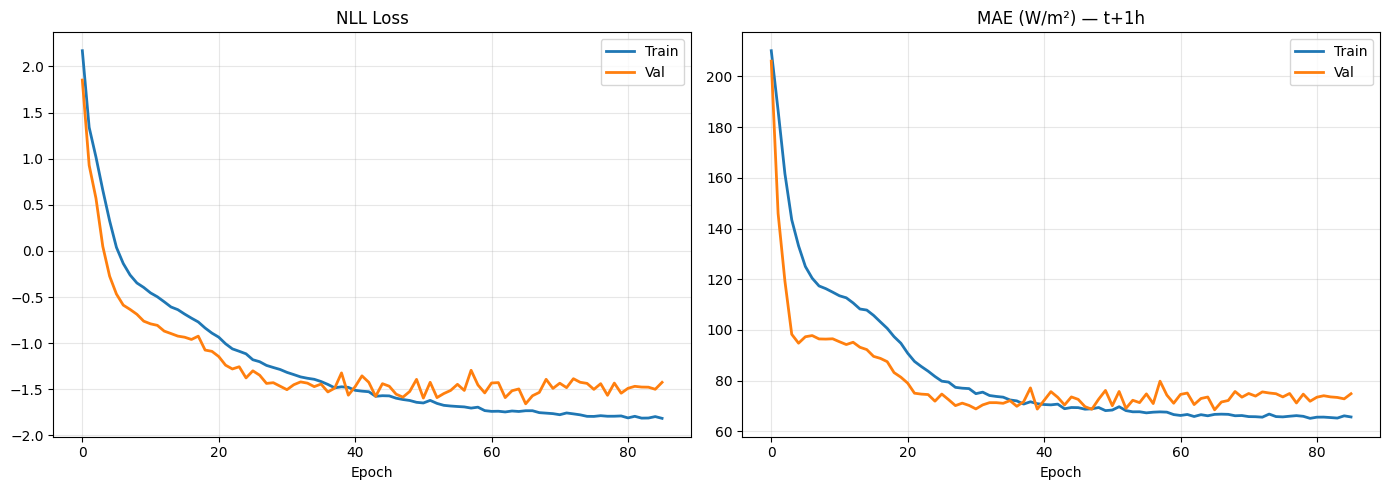

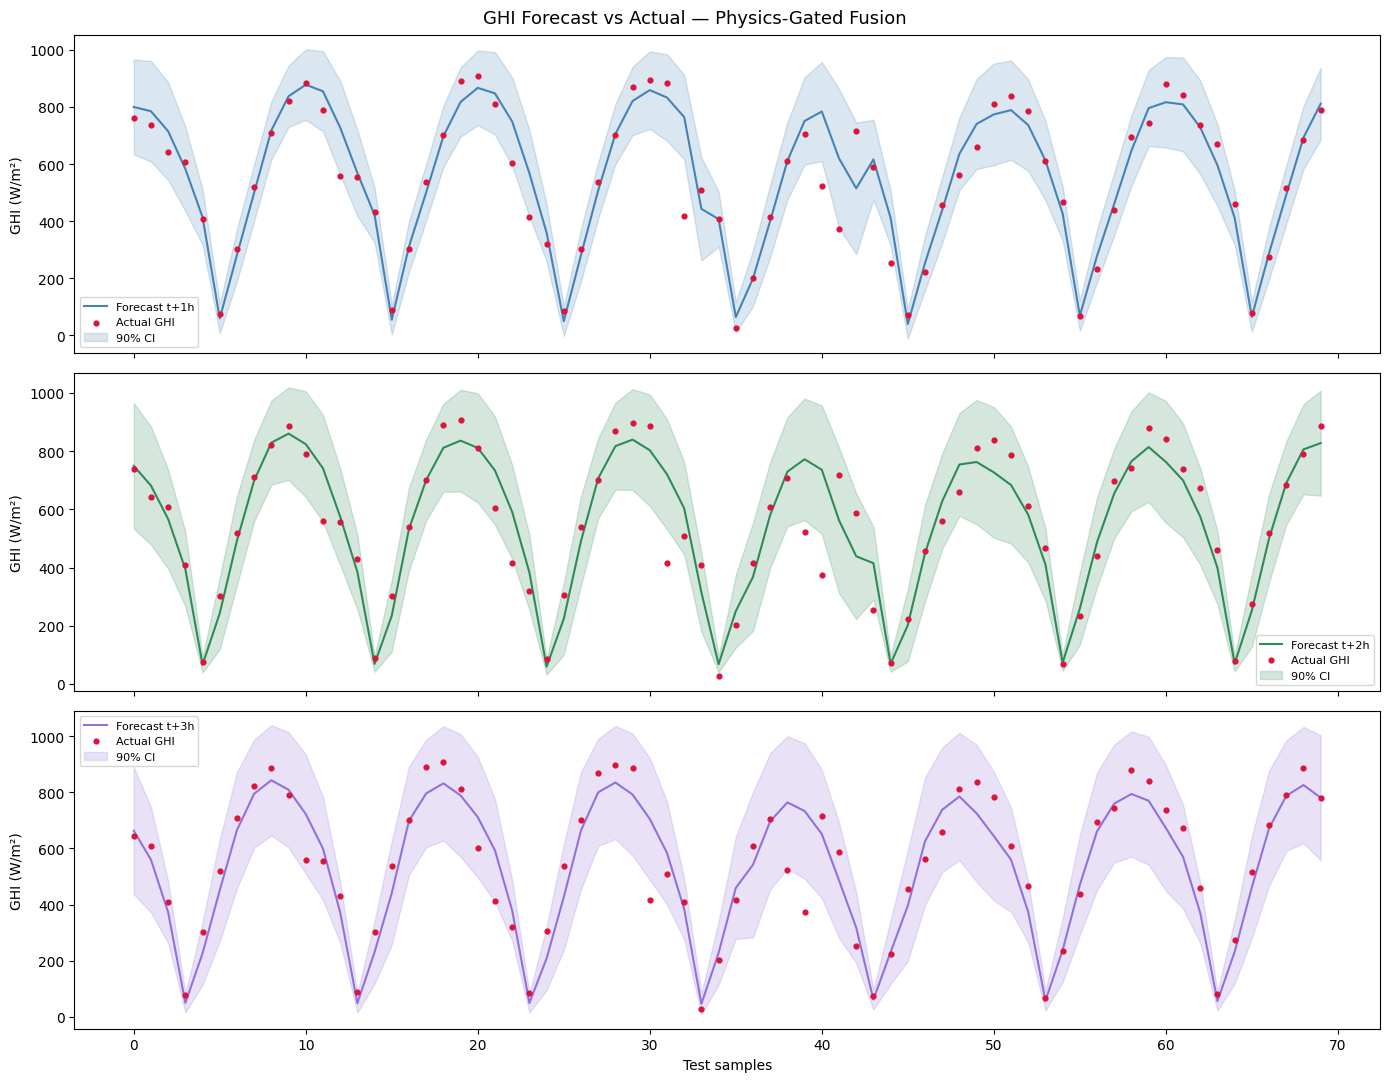

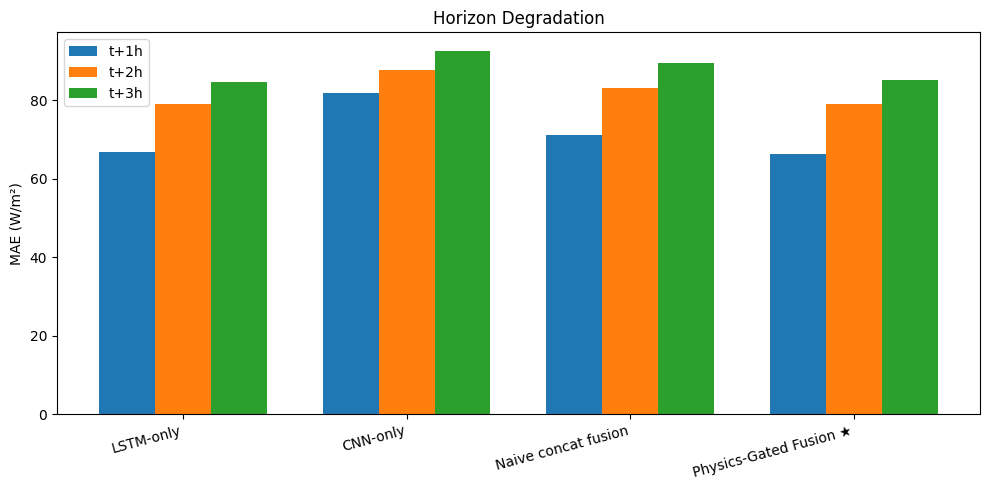

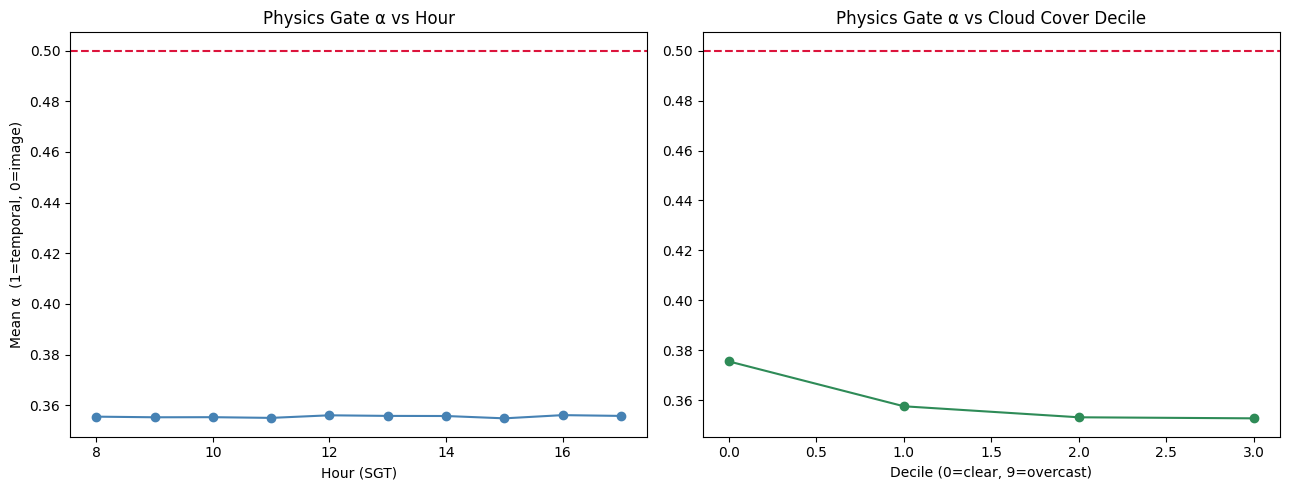

In [30]:
# 9a. Training curves
if history and len(history["train_nll"]) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history["train_nll"], label="Train", lw=2)
    axes[0].plot(history["val_nll"],   label="Val",   lw=2)
    axes[0].set_title("NLL Loss"); axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history["train_mae"], label="Train", lw=2)
    axes[1].plot(history["val_mae"],   label="Val",   lw=2)
    axes[1].set_title("MAE (W/m²) — t+1h"); axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{RESULTS}/plots/training_curves.png", dpi=150)
    plt.show()

# 9b. Forecast vs Actual
N = 70
mu_p, sig_p, tar_p = pred_cache["full"][:N], pred_cache["full"][1][:N], pred_cache["full"][2][:N]
mu_p, sig_p, tar_p = [x[:N] for x in pred_cache["full"]]
fig, axs = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
for h, col in enumerate(["steelblue","seagreen","mediumpurple"]):
    lo = mu_p[:,h] - 1.645*sig_p[:,h]; hi = mu_p[:,h] + 1.645*sig_p[:,h]
    axs[h].plot(mu_p[:,h], color=col, lw=1.5, label=f"Forecast t+{h+1}h")
    axs[h].scatter(range(N), tar_p[:,h], color="crimson", s=12, zorder=5, label="Actual GHI")
    axs[h].fill_between(range(N), lo, hi, alpha=0.2, color=col, label="90% CI")
    axs[h].set_ylabel("GHI (W/m²)"); axs[h].legend(fontsize=8)
axs[2].set_xlabel("Test samples")
plt.suptitle("GHI Forecast vs Actual — Physics-Gated Fusion", fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS}/plots/forecast_vs_actual.png", dpi=150); plt.show()

# 9c. Horizon degradation
deep = list(eval_horizons.keys())
h1 = [eval_horizons[n][0]["MAE_Wm2"] for n in deep]
h2 = [eval_horizons[n][1]["MAE_Wm2"] for n in deep]
h3 = [eval_horizons[n][2]["MAE_Wm2"] for n in deep]
x, w = np.arange(len(deep)), 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x-w, h1, w, label="t+1h"); ax.bar(x, h2, w, label="t+2h"); ax.bar(x+w, h3, w, label="t+3h")
ax.set_xticks(x); ax.set_xticklabels(deep, rotation=15, ha="right")
ax.set_ylabel("MAE (W/m²)"); ax.set_title("Horizon Degradation"); ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS}/plots/horizon_degradation.png", dpi=150); plt.show()

# 9d. Physics gate analysis
model_full.eval()
all_alpha, all_hours, all_cloud = [], [], []
with torch.no_grad():
    for batch in test_loader:
        tab = batch["tabular_seq"].to(device); img = batch["image"].to(device)
        fc  = batch["future_clearsky"].to(device); gf = batch["gate_features"].to(device)
        _, _, alpha, _ = model_full(tab, img, fc, gf, return_attn=True)
        all_alpha.append(alpha.cpu().view(-1))
        all_cloud.append(batch["gate_features"][:,1]*100)
        all_hours.append(test_dataset.df.iloc[
            [test_dataset.valid_indices[i] for i in range(len(batch["idx"]))]]["hour"].values)

all_alpha = torch.cat(all_alpha).numpy()
all_cloud = torch.cat(all_cloud).numpy()
all_hours = np.concatenate(all_hours)

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
gdf = pd.DataFrame({"alpha": all_alpha, "hour": all_hours})
hm  = gdf.groupby("hour")["alpha"].mean()
axs[0].plot(hm.index, hm.values, marker="o", color="steelblue")
axs[0].axhline(0.5, color="crimson", linestyle="--")
axs[0].set_title("Physics Gate α vs Hour"); axs[0].set_xlabel("Hour (SGT)")
axs[0].set_ylabel("Mean α  (1=temporal, 0=image)")
cdf = pd.DataFrame({"alpha": all_alpha, "cloud": all_cloud})
cdf["dec"] = pd.qcut(cdf["cloud"], 10, duplicates="drop", labels=False)
cm  = cdf.groupby("dec")["alpha"].mean()
axs[1].plot(cm.index, cm.values, marker="o", color="seagreen")
axs[1].axhline(0.5, color="crimson", linestyle="--")
axs[1].set_title("Physics Gate α vs Cloud Cover Decile")
axs[1].set_xlabel("Decile (0=clear, 9=overcast)")
plt.tight_layout()
plt.savefig(f"{RESULTS}/plots/gate_analysis.png", dpi=150); plt.show()


In [9]:
import json
import numpy as np
import pandas as pd

CSV_PATH = "data/combined_dataset.csv"

TABULAR_COLS = [
    "clearsky_ratio", "cloud_cover", "temperature_2m",
    "rain", "wind_speed_10m", "relative_humidity_2m",
    "sin_hour", "cos_hour", "sin_month", "cos_month",
    "ghi_lag1",
]

df = pd.read_csv(CSV_PATH)
df["timestamp"]      = pd.to_datetime(df["timestamp"])
df                   = df.sort_values("timestamp").reset_index(drop=True)
df["clearsky_ratio"] = df["ghi"] / (df["ghi_clearsky"] + 1e-6)
df["hour"]           = df["timestamp"].dt.hour
df["month"]          = df["timestamp"].dt.month
df["sin_hour"]       = np.sin(2 * np.pi * df["hour"] / 24)
df["cos_hour"]       = np.cos(2 * np.pi * df["hour"] / 24)
df["sin_month"]      = np.sin(2 * np.pi * df["month"] / 12)
df["cos_month"]      = np.cos(2 * np.pi * df["month"] / 12)
df["ghi_lag1"]       = df["ghi"].shift(1).fillna(0)

# Same 70% train split as Section 5
n       = len(df.dropna(subset=TABULAR_COLS + ["ghi"]))
df_clean = df.dropna(subset=TABULAR_COLS + ["ghi"]).copy()
train_df = df_clean.iloc[:int(n * 0.70)]

tab_arr  = train_df[TABULAR_COLS].values.astype(np.float32)
ghi_arr  = train_df["ghi"].values.astype(np.float32)

stats = {
    "mean":     tab_arr.mean(axis=0).tolist(),
    "std":      (tab_arr.std(axis=0) + 1e-6).tolist(),
    "ghi_mean": float(ghi_arr.mean()),
    "ghi_std":  float(ghi_arr.std() + 1e-6),
}

with open('./train_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

print("Saved ✓")
print(json.dumps(stats, indent=2))

Saved ✓
{
  "mean": [
    0.7078616619110107,
    86.82535552978516,
    28.723676681518555,
    0.7702692151069641,
    9.131843566894531,
    77.29169464111328,
    -0.09628615528345108,
    -0.7338259816169739,
    0.20779989659786224,
    -0.03583775833249092,
    474.8313293457031
  ],
  "std": [
    0.25927191972732544,
    23.720548629760742,
    2.288381814956665,
    2.003291606903076,
    4.361176490783691,
    11.002728462219238,
    0.630290687084198,
    0.23444347083568573,
    0.6829032301902771,
    0.6994146108627319,
    259.7521057128906
  ],
  "ghi_mean": 474.9627990722656,
  "ghi_std": 259.6896667480469
}
